# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [94]:
from __future__ import annotations

import torch
from torch import nn



## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [95]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.W = nn.Parameter(torch.empty(out_features, in_features))
        
        if bias:
            self.b = nn.Parameter(torch.empty(out_features))
        else:
            self.b = None

        torch.nn.init.xavier_uniform_(self.W)
        if self.b is not None:
            nn.init.zeros_(self.b)
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = torch.matmul(x, self.W.T) 
        if self.b is not None:
            y += self.b
        return y
def test_my_linear_forward():
    layer = Linear(in_features=3, out_features=2, bias=True)

    with torch.no_grad():
        layer.W.copy_(torch.tensor([
            [1.0, 2.0, 3.0],
            [4.0, 5.0, 6.0],
        ]))
        layer.b.copy_(torch.tensor([0.5, -1.0]))

    x = torch.tensor([
        [1.0, 0.0, -1.0],
        [2.0, 1.0, 0.0],
    ])

    y = layer(x)

    expected = torch.tensor([
        [-1.5, -3.0],
        [ 4.5, 12.0],
    ])

    assert torch.allclose(y, expected)
print(test_my_linear_forward())


None


In [96]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [97]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training or self.p == 0:
            return x
        mask = (torch.rand_like(x) > self.p).to(x.dtype)
        return x * mask * (1/1-self.p)


## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [98]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))

        else:
            self.weight = None
            self.bias = None
            
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        
        mean = x.mean(dim=-1, keepdim = True)
        var = x.var(dim=-1, keepdim = True, unbiased=False)
        y = (x - mean) / torch.sqrt(var + self.eps)

        if self.elementwise_affine:
            y = y*self.weight + self.bias
        
        return y


In [99]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = x.square().mean(dim=-1, keepdim=True)
        return  x / torch.sqrt(rms + self.eps) * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [100]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(Linear(in_dim, hidden_dim))
        self.layers.append(nn.GELU())

        if use_layernorm:
            self.layers.append(LayerNorm(hidden_dim))

        for _ in range(depth - 2):
            self.layers.append(Linear(hidden_dim, hidden_dim))
            self.layers.append(nn.GELU())

            if use_layernorm:
                self.layers.append(LayerNorm(hidden_dim))
        self.layers.append(Linear(hidden_dim, out_dim))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x
    


In [101]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.ffn = nn.Sequential(
            Linear(d_model, d_ff),
            nn.GELU(),
            Linear(d_ff, d_model)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ffn(x)

In [102]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [103]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [104]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size = 64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size = 256, shuffle=False, num_workers=4, pin_memory=True)


In [105]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_prob = nn.LogSoftmax(-1)(logits)

    correct_log_probs = log_prob[torch.arange(logits.shape[0]), targets]

    return -correct_log_probs.mean()

import torch.nn.functional as F
def test_cross_entropy_from_logits():
    logits = torch.tensor([
        [1000.0, 1001.0, 999.0],
        [-1000.0, -999.0, -1001.0],
    ])
    targets = torch.tensor([1, 1])

    actual = cross_entropy_from_logits(logits, targets)
    expected = F.cross_entropy(logits, targets)

    assert torch.allclose(actual, expected, atol=1e-6), (actual, expected)

print(test_cross_entropy_from_logits())

None


In [106]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.linear = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.linear(x)

In [107]:
def accuracy(model,loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = logits.argmax(dim=-1)

            correct += (preds == y).sum().item()
            total += y.numel()

    return correct / total


In [108]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    train_loss = []

    model.to(device)

    for epoch in range(epochs):
        model.train()

        for images, gt in train_data_loader:
            optimizer.zero_grad()
            logits = model(images)
            loss = cross_entropy_from_logits(logits, gt)
            
            loss.backward()
            optimizer.step()

            train_loss.append(loss.item())

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_data_loader:
                logits = model(x)
                preds = logits.argmax(dim=-1)

                correct += (preds == y).sum().item()
                total += y.numel()

        acc = correct / total
        print(f"epoch {epoch + 1}: test accuracy = {acc:.4f}")

    return train_loss


/home/sebi/playground_ws/ethz-course-2026/hw1_pytorch_tutorial/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1: test accuracy = 0.9545
epoch 2: test accuracy = 0.9691
epoch 3: test accuracy = 0.9705
epoch 4: test accuracy = 0.9740
epoch 5: test accuracy = 0.9717
final test accuracy: 0.9717


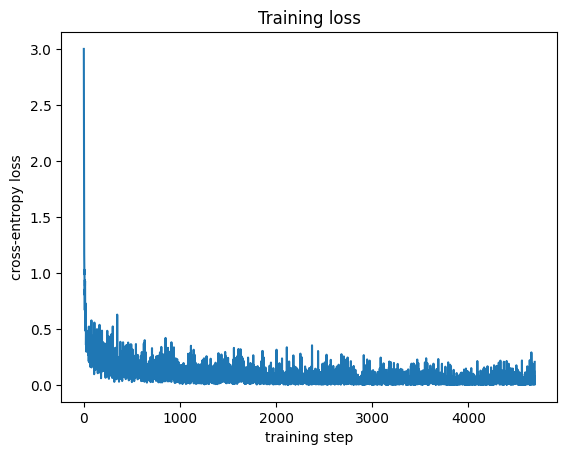

In [111]:
import matplotlib.pyplot as plt

model = nn.Sequential(
    nn.Flatten(),
    MLP(784, 128, 128, depth=3, use_layernorm=True),
    ClassificationHead(128, 10),
)

losses = train_classifier(
    model,
    train_loader,
    test_loader,
    lr=1e-3,
    epochs=5,
)

print("final test accuracy:", accuracy(model,test_loader))

plt.plot(losses)
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title("Training loss")
plt.show()

